# do market prices improve a public temperature forecast?

this exploratory reconstruction covers central park from june through august 2025. june supplies training data, july is validation, and august is the later evaluation period. predictions are taken 12 and 6 hours before the settlement day starts.

inputs are saved kalshi records, archived noaa ndfd forecasts, and ncei daily observations. the notebook reads the completed panel and saved evaluation. it makes no network request and fits no model. the first check rejects an incomplete panel or results from different inputs.

the question concerns forecast information. hourly candle closes and reconstructed archive availability cannot establish executable trading performance.

In [1]:
import hashlib
import json
import math
import sqlite3
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
plt.style.use(repo / "config/styles/custom_qb_dark_darien.mplstyle")
study = repo / "outputs/historical-study"
panel_path = study / "panel.json"
results_path = study / "analysis/historical-results.json"
protocol_path = repo / "config/historical-protocol.json"
for path in (panel_path, results_path, protocol_path):
    if not path.is_file():
        raise FileNotFoundError(f"complete the saved historical study before execution: {path}")
panel = json.loads(panel_path.read_bytes())
results = json.loads(results_path.read_bytes())
protocol = json.loads(protocol_path.read_bytes())


def canonical_sha(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, allow_nan=False).encode()).hexdigest()


assert panel["data_origin"] == results["data_origin"] == "empirical_historical"
assert panel["complete_requested_dates"], "collection is incomplete; this is not the final cohort."
assert canonical_sha(panel) == results["input_panel_sha256"], "stale panel evaluation."
assert canonical_sha(protocol) == results["input_protocol_sha256"], "different input protocol."
assert panel["protocol"] == protocol
assert canonical_sha(results["protocol"]) == results["protocol_sha256"]
assert {r["case_id"] for r in panel["cases"]} == {r["case_id"] for r in results["case_results"]}
fit = results["fit"]
methods = ("public_only", "market_only", "equal_blend", "trained_blend")
pd.set_option("display.max_colwidth", 90)
display(
    pd.DataFrame(
        [
            {"input": "panel", "sha256": results["input_panel_sha256"]},
            {"input": "protocol", "sha256": results["input_protocol_sha256"]},
            {
                "input": "saved results bytes",
                "sha256": hashlib.sha256(results_path.read_bytes()).hexdigest(),
            },
        ]
    )
)

,input,sha256
0,panel,d4b482321ab309083f0dd35307f2c2fefff84fe93946bf1e04a14d9f18e8c110
1,protocol,e185b37c4217517558efde71e56302d16e2103197340d63792376ce680c821ef
2,saved results bytes,33812365c39e4181869ac42c51499b85561b4e70fa1c1b61d8581a9129c64fe6


## cohort and missingness

one station-day is one realized event. two horizons share its outcome, and the temperature bins are mutually exclusive outcomes of that event. none of those repetitions increases the number of independent dates.

the sql below counts every saved case by split and horizon. collection exclusions and labels unavailable at fitting time are separate: the latter may be scored descriptively but did not enter the fitted model. no case is removed because a method scored poorly or because ncei disagrees with settlement.

In [2]:
records = results["case_results"]
scalar_keys = (
    "case_id",
    "event_id",
    "outcome_date",
    "horizon_hours",
    "split",
    "as_of_at",
    "outcome_window_start_at",
    "outcome_window_end_at",
    "outcome_available_at",
    "forecast_f",
    "forecast_available_at",
    "outcome_f",
    "ncei_tmax_f",
    "ncei_matches_settlement",
    "public_mean_f",
    "disagreement_l1",
    "disagreement_group",
    "used_for_fit",
    "public_interval90_contains_outcome",
    "market_probability_sum_before_normalization",
)
rows = []
for r in records:
    forecast = r["forecast"]
    row = {}
    for key in scalar_keys:
        row[key] = r.get(key)
    row.update(
        {
            "bin_count": len(r["bins"]),
            "forecast_reference_at": forecast["issued_at"],
            "forecast_valid_start_at": forecast["valid_start_at"],
            "forecast_valid_end_at": forecast["valid_end_at"],
            "bulletin_nominal_at": forecast["object"]["nominal_at"],
            "archive_modified_at": forecast["object"]["last_modified_at"],
            "forecast_source_sha256": forecast["source_sha256"],
            "forecast_message": forecast["message_number"],
            "grid_distance_km": forecast["grid_distance_km"],
            "max_candle_age_minutes": max(
                m["candle_age_minutes"] for m in r["market_observations"]
            ),
            "mean_candle_spread": statistics.fmean(m["spread"] for m in r["market_observations"]),
            "public_interval90_lower_f": r["public_predictive_interval90_f"][0],
            "public_interval90_upper_f": r["public_predictive_interval90_f"][1],
        }
    )
    rows.append(row)
cases = pd.DataFrame(rows)
con = sqlite3.connect(":memory:")
cases.to_sql("cases", con, index=False)
inventory = pd.read_sql_query(
    """
    SELECT split, horizon_hours, COUNT(*) AS cases,
           COUNT(DISTINCT event_id) AS events,
           COUNT(DISTINCT outcome_date) AS dates,
           SUM(used_for_fit) AS fitted_cases,
           SUM(bin_count) AS bin_observations
    FROM cases GROUP BY split, horizon_hours
    ORDER BY CASE split WHEN 'train' THEN 1 WHEN 'validation' THEN 2 ELSE 3 END,
             horizon_hours DESC
""",
    con,
)
display(inventory)
display(pd.DataFrame([panel["counts"]]))
assert cases["case_id"].is_unique
assert cases.groupby("event_id")["split"].nunique().max() == 1
assert cases.groupby("event_id")["outcome_f"].nunique().max() == 1
assert cases["event_id"].nunique() == results["cohort"]["events"]

,split,horizon_hours,cases,events,dates,fitted_cases,bin_observations
0,train,12,30,30,30,29,180
1,train,6,30,30,30,29,180
2,validation,12,31,31,31,0,186
3,validation,6,31,31,31,0,186
4,holdout,12,31,31,31,0,186
5,holdout,6,31,31,31,0,186


,cases,events,exclusions,processed_dates,requested_dates
0,184,92,0,92,92


In [3]:
exclusions = pd.DataFrame(results["exclusions"])
display(pd.DataFrame(results["split_horizon_inventory"]))
if exclusions.empty:
    print("no collection exclusions were recorded.")
else:
    display(pd.Series(results["exclusion_reason_counts"], name="excluded_records").to_frame())
    display(exclusions.head(12))
fit_excluded = cases[cases["case_id"].isin(fit["excluded_training_case_ids"])]
print("fit cutoff:", fit["fit_at"])
print("training label availability:", fit["training_label_availability"])
display(fit_excluded[["case_id", "outcome_available_at", "split"]])
expected_dates = pd.date_range(protocol["start_date"], protocol["end_date"], freq="D")
observed_dates = pd.to_datetime(cases["outcome_date"].unique())
print(
    "dates without any retained case:",
    expected_dates.difference(observed_dates).strftime("%Y-%m-%d").tolist(),
)
print("retained unique dates:", len(observed_dates), "; requested:", len(expected_dates))

,cases,dates,events,horizon_hours,split
0,30,30,30,12,train
1,30,30,30,6,train
2,31,31,31,12,validation
3,31,31,31,6,validation
4,31,31,31,12,holdout
5,31,31,31,6,holdout


no collection exclusions were recorded.
fit cutoff: 2025-06-30T17:00:00+00:00
training label availability: verified_for_all_fitted_cases


,case_id,outcome_available_at,split
58,KXHIGHNY-25JUN30-6h,2025-07-01T13:08:20.849350+00:00,train
59,KXHIGHNY-25JUN30-12h,2025-07-01T13:08:20.849350+00:00,train


dates without any retained case: []
retained unique dates: 92 ; requested: 92


## verify the archived contract definition

the saved june 1 market rules name the nws daily climate report for central park. that archived definition anchors this cohort.

retrieval now does not prove that the text is an unchanged contemporaneous snapshot. the helper below verifies each body against its receipt before reading it, and the lineage table keeps the rule, forecast, and candle hashes visible.

In [4]:
raw = study / "raw"
metadata_by_hash = {}
for path in raw.glob("*.json"):
    assert path.stat().st_size <= 128 * 1024, f"unexpectedly large source receipt: {path}"
    meta = json.loads(path.read_bytes())
    metadata_by_hash[meta["content_sha256"]] = (path, meta)


def verified_source(content_sha, *, as_json=False):
    receipt_path, meta = metadata_by_hash[content_sha]
    body_path = receipt_path.with_suffix(".body")
    assert body_path.stat().st_size == meta["bytes"]
    digest = hashlib.sha256()
    with body_path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    assert digest.hexdigest() == content_sha, f"source hash mismatch: {body_path}"
    if as_json:
        assert meta["bytes"] <= 2 * 1024 * 1024, "bounded json example exceeded 2 mib."
        return json.loads(body_path.read_bytes()), meta
    return body_path, meta


pilot = next(r for r in records if r["outcome_date"] == "2025-06-01" and r["horizon_hours"] == 12)
archived, rule_meta = verified_source(pilot["market_rules_source_sha256"][0], as_json=True)
pilot_markets = []
for m in archived['markets']:
    if m['event_ticker'] == pilot['event_id']:
        pilot_markets.append(m)
assert pilot_markets
historical_rule = pilot_markets[0]["rules_primary"]
assert "Central Park, New York" in historical_rule
assert "National Weather Service's Climatological Report (Daily)" in historical_rule
display(
    pd.DataFrame(
        [
            {
                "record": "archived june 1 market",
                "retrieved_at": rule_meta["received_at"],
                "definition_check": "central park and nws daily climate report named",
            },
        ]
    )
)
lineage = []
for label, content_sha in [
    ("June 1 rules", pilot["market_rules_source_sha256"][0]),
    ("june 1 noaa forecast", pilot["forecast"]["source_sha256"]),
    ("one june 1 candle response", next(iter(pilot["market_source_sha256"].values()))),
]:
    _, meta = verified_source(content_sha)
    lineage.append(
        {
            "record": label,
            "bytes": meta["bytes"],
            "sha256": content_sha,
            "retrieved_at": meta["received_at"],
        }
    )
display(pd.DataFrame(lineage))

,record,retrieved_at,definition_check
0,archived june 1 market,2026-09-14T13:19:39.509593+00:00,central park and nws daily climate report named


,record,bytes,sha256,retrieved_at
0,June 1 rules,14282,b2c1397b4a0836255b8625e5ca3a9f3f5c78ee454041a3e0c83a123f4232a2f2,2026-09-14T13:19:39.509593+00:00
1,june 1 noaa forecast,3142949,4f4887a39454f5bd09a21f41314dd802805cc25c2f563417aa6034b411738494,2026-09-14T13:26:15.559531+00:00
2,one june 1 candle response,2977,cba80ce5eea018d2bc7e07e54b870e2a0043e40f61df434746c1c0ca77f556a2,2026-09-14T13:21:15.780485+00:00


## forecast vintage, availability bound, and target window

the outcome day is midnight-to-midnight eastern standard time, encoded as 05z–05z. ndfd maxt covers 12z–00z: its daytime maximum is a predictor for a different target. a residual distribution learned from earlier matched outcomes provides the mapping.

the afternoon grib messages also exposed a decoder bug: their reference-to-valid offsets can be expressed in minutes. the corrected reader accepts minutes and hours, retains fractional-hour leads, and verifies the full 12-hour interval. a message is selected by its encoded target window rather than by a fixed position in the bulletin.

the availability rule uses the later of s3 modification time and nominal bulletin time plus the specified delay; the decoded reference must also precede the checkpoint. this is a documented historical bound, not an observed first-publication timestamp. download time remains separate.

In [5]:
time_columns = []
for c in cases:
    if c.endswith('_at'):
        time_columns.append(c)
for column in time_columns:
    cases[column] = pd.to_datetime(cases[column], utc=True)
cases["archive_lag_minutes"] = (
    cases["archive_modified_at"] - cases["bulletin_nominal_at"]
).dt.total_seconds() / 60
cases["availability_slack_minutes"] = (
    cases["as_of_at"] - cases["forecast_available_at"]
).dt.total_seconds() / 60
cases["forecast_lead_hours"] = (
    cases["forecast_valid_start_at"] - cases["forecast_reference_at"]
).dt.total_seconds() / 3600
assert (cases["forecast_available_at"] <= cases["as_of_at"]).all()
assert (cases["forecast_reference_at"] <= cases["as_of_at"]).all()
assert (
    (cases["outcome_window_start_at"] - cases["as_of_at"]).dt.total_seconds()
    == cases["horizon_hours"] * 3600
).all()
assert (
    (cases["forecast_valid_end_at"] - cases["forecast_valid_start_at"]) == pd.Timedelta(hours=12)
).all()
assert (cases["max_candle_age_minutes"] <= protocol["market_max_candle_age_minutes"]).all()
display(
    cases[cases["outcome_date"] == "2025-06-01"][
        [
            "case_id",
            "bulletin_nominal_at",
            "archive_modified_at",
            "forecast_reference_at",
            "forecast_available_at",
            "as_of_at",
            "forecast_lead_hours",
            "forecast_valid_start_at",
            "forecast_valid_end_at",
            "outcome_window_start_at",
            "outcome_window_end_at",
            "forecast_message",
        ]
    ]
)
print(
    "closest grid-cell distance range, km:",
    cases["grid_distance_km"].min(),
    cases["grid_distance_km"].max(),
)

,case_id,bulletin_nominal_at,archive_modified_at,forecast_reference_at,forecast_available_at,as_of_at,forecast_lead_hours,forecast_valid_start_at,forecast_valid_end_at,outcome_window_start_at,outcome_window_end_at,forecast_message
0,KXHIGHNY-25JUN01-6h,2025-05-31 22:16:00+00:00,2025-05-31 22:18:24+00:00,2025-05-31 22:30:00+00:00,2025-05-31 22:46:00+00:00,2025-05-31 23:00:00+00:00,13.5,2025-06-01 12:00:00+00:00,2025-06-02 00:00:00+00:00,2025-06-01 05:00:00+00:00,2025-06-02 05:00:00+00:00,2
1,KXHIGHNY-25JUN01-12h,2025-05-31 16:16:00+00:00,2025-05-31 16:21:15+00:00,2025-05-31 16:30:00+00:00,2025-05-31 16:46:00+00:00,2025-05-31 17:00:00+00:00,19.5,2025-06-01 12:00:00+00:00,2025-06-02 00:00:00+00:00,2025-06-01 05:00:00+00:00,2025-06-02 05:00:00+00:00,2


closest grid-cell distance range, km: 0.37329364200423326 0.37329364200423326


archive_lag_minutes                      \
                              min    median       max   
horizon_hours                                           
6                        1.133333  4.708333  7.683333   
12                       1.350000  3.958333  7.000000   

              availability_slack_minutes              max_candle_age_minutes  \
                                     min median   max                    min   
horizon_hours                                                                  
6                                   14.0   14.0  43.0                    0.0   
12                                  14.0   14.0  74.0                    0.0   

                          mean_candle_spread                      \
              median  max                min    median       max   
horizon_hours                                                      
6                0.0  0.0           0.021667  0.037500  0.225000   
12               0.0  0.0           0.023333  0.041667  0.186667   

              market_probability_sum_before_normalization                 
                                                      min  median    max  
horizon_hours                                                             
6                                                   0.975  1.0525  1.415  
12                                                  0.975  1.0350  1.490

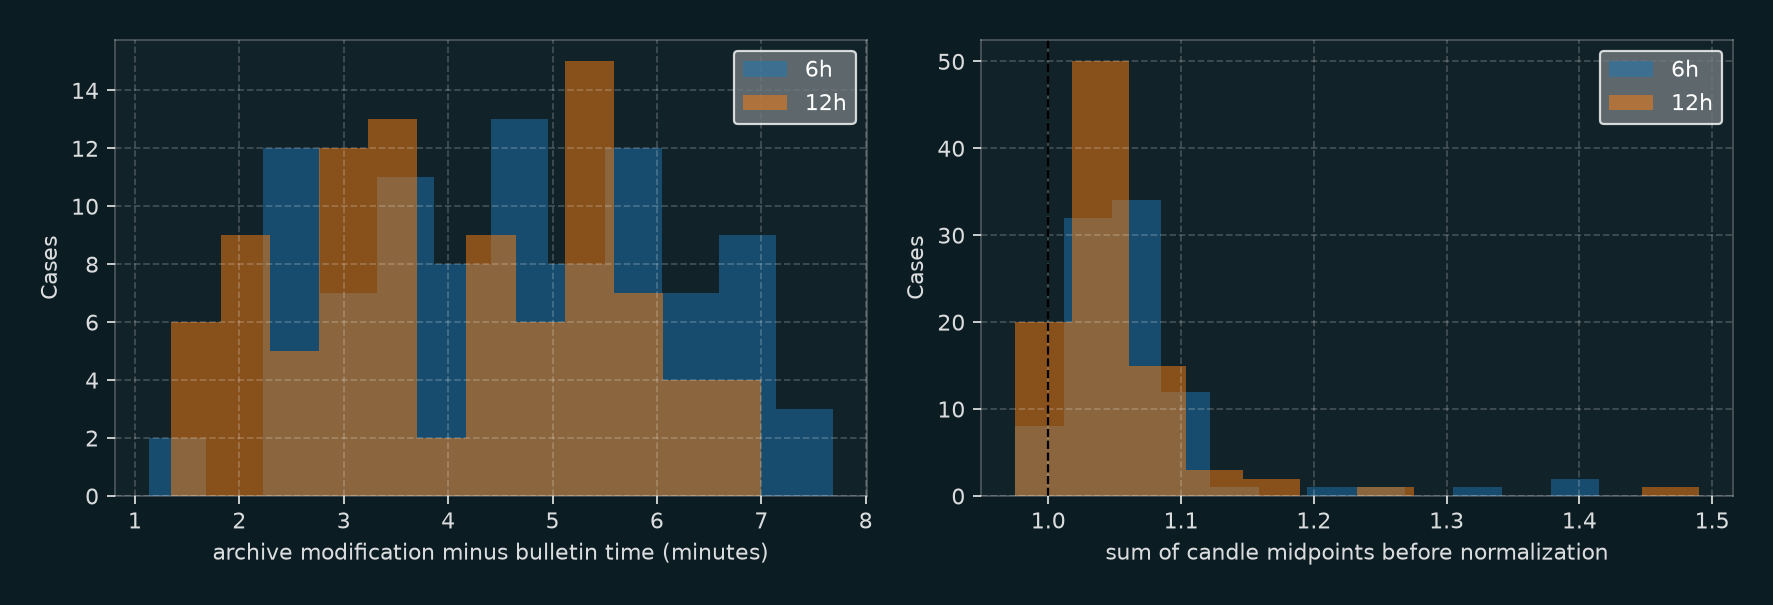

the same source may serve multiple cases. histogram counts are not independent events.
midpoints are normalized to a probability vector; this adjustment is visible above.


In [6]:
display(
    cases.groupby("horizon_hours")[
        [
            "archive_lag_minutes",
            "availability_slack_minutes",
            "max_candle_age_minutes",
            "mean_candle_spread",
            "market_probability_sum_before_normalization",
        ]
    ].agg(["min", "median", "max"])
)
_, axes = plt.subplots(1, 2, figsize=(11, 3.7))
for horizon, group in cases.groupby("horizon_hours"):
    axes[0].hist(group["archive_lag_minutes"], bins=12, alpha=.5, label=f"{horizon}h")
    axes[1].hist(
        group["market_probability_sum_before_normalization"],
        bins=12,
        alpha=.5,
        label=f"{horizon}h",
    )
axes[0].set(xlabel="archive modification minus bulletin time (minutes)", ylabel="Cases")
axes[1].set(xlabel="sum of candle midpoints before normalization", ylabel="Cases")
axes[1].axvline(1, color="black", linestyle="--", linewidth=1)
for ax in axes:
    ax.legend()
plt.tight_layout(pad=1.5)
plt.show()
print("the same source may serve multiple cases. histogram counts are not independent events.")
print("midpoints are normalized to a probability vector; this adjustment is visible above.")

## reconcile labels without selecting on the answer

settlement temperatures come from the archived contracts and their reported winning bins. ncei daily tmax is an independent reconciliation check. the table uses one row per event, so two horizons do not double its count. a mismatch stays visible and does not automatically remove a case.

final observations are outcomes here, not historical predictors. labels entering the fitted model must have been available before its saved fit cutoff.

In [7]:
events = cases.sort_values("horizon_hours").drop_duplicates("event_id").copy()
events["ncei_minus_settlement_f"] = events["ncei_tmax_f"] - events["outcome_f"]
reconciliation = pd.DataFrame(
    [
        {
            "events": len(events),
            "NCEI_available": int(events["ncei_tmax_f"].notna().sum()),
            "exact_matches": int(events["ncei_minus_settlement_f"].eq(0).sum()),
            "differences": int(
                events["ncei_minus_settlement_f"].notna().sum()
                - events["ncei_minus_settlement_f"].eq(0).sum()
            ),
        }
    ]
)
display(reconciliation)
display(
    events.loc[
        events["ncei_minus_settlement_f"].ne(0),
        ["outcome_date", "outcome_f", "ncei_tmax_f", "ncei_minus_settlement_f"],
    ]
)
training = cases[cases["used_for_fit"]].copy()
assert len(training) == fit["training_cases"]
assert set(training["case_id"]) == set(fit["training_case_ids"])
assert training["split"].eq("train").all()
known_labels = training["outcome_available_at"].dropna()
assert (known_labels <= pd.Timestamp(fit["fit_at"])).all()
print(
    "training rows without a label-availability timestamp:",
    training["outcome_available_at"].isna().sum(),
)

,events,NCEI_available,exact_matches,differences
0,92,92,91,1


,outcome_date,outcome_f,ncei_tmax_f,ncei_minus_settlement_f
2,2025-06-02,66.0,71.0,5.0


training rows without a label-availability timestamp: 0


## what the public forecast learned

the public-only model adds the training mean residual, `settlement high − NDFD MaxT`, to each forecast. its predictive standard deviation is the training residual sample standard deviation, subject to the recorded floor. the model pools the two horizons; it does not assume their errors are independent for inference.

the histogram and time trace reveal the fitted errors directly. training scores are in-sample. the saved parameters remain fixed for july and august; this notebook does not choose a new distribution after inspecting later outcomes.

,saved_fit
fit_at,2025-06-30T17:00:00+00:00
training_cases,58
training_events,29
training_dates,29
residual_mean_f,-1.467241
residual_sample_std_f,2.993507
residual_std_floor_f,1.0
residual_std_f,2.993507


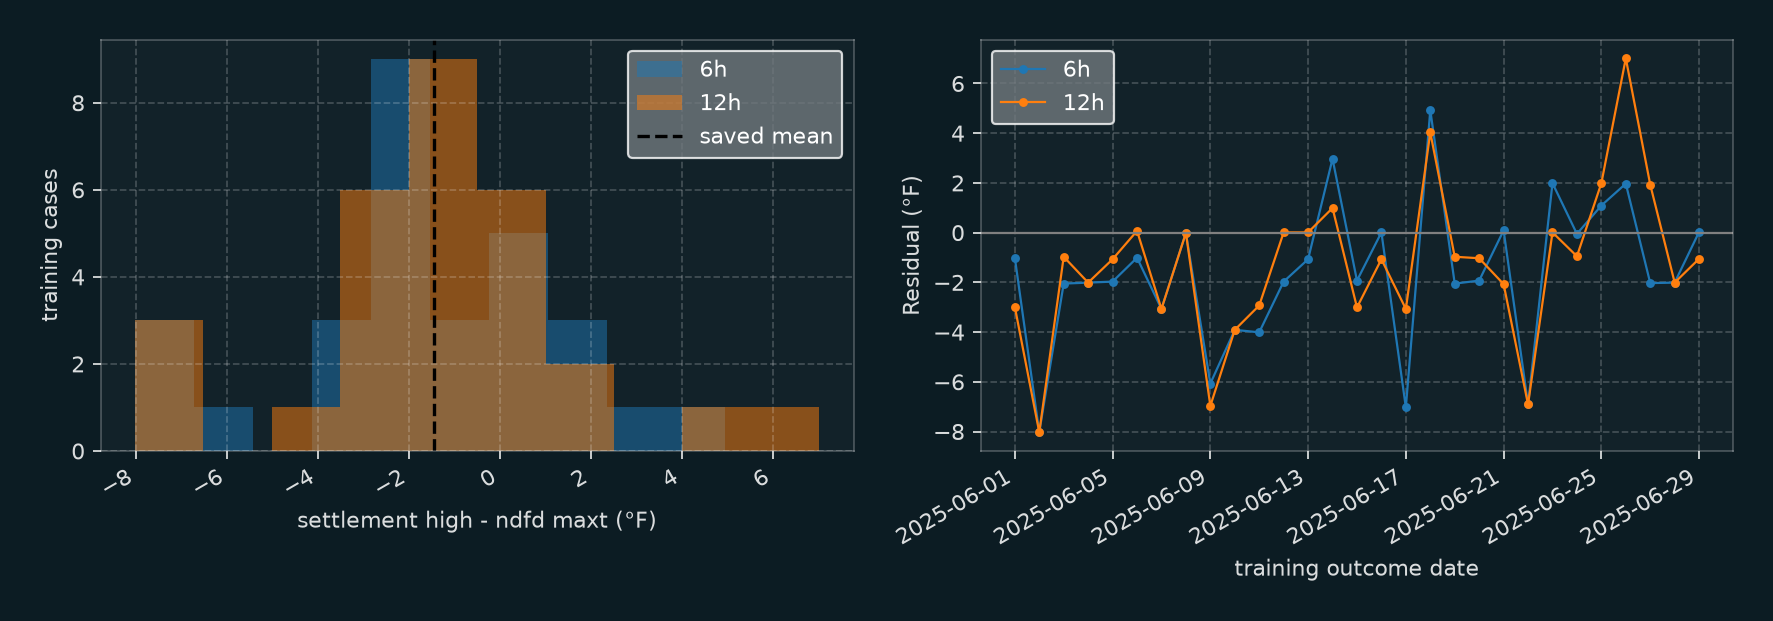

In [8]:
training["residual_f"] = training["outcome_f"] - training["forecast_f"]
display(
    pd.Series(
        {
            key: fit[key]
            for key in (
                "fit_at",
                "training_cases",
                "training_events",
                "training_dates",
                "residual_mean_f",
                "residual_sample_std_f",
                "residual_std_floor_f",
                "residual_std_f",
            )
        },
        name="saved_fit",
    ).to_frame()
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for horizon, group in training.groupby("horizon_hours"):
    axes[0].hist(group["residual_f"], bins=10, alpha=.5, label=f"{horizon}h")
    axes[1].plot(
        pd.to_datetime(group["outcome_date"]),
        group["residual_f"],
        marker=".",
        linewidth=1,
        label=f"{horizon}h",
    )
axes[0].axvline(fit["residual_mean_f"], color="black", linestyle="--", label="saved mean")
axes[0].set(xlabel="settlement high - ndfd maxt (°F)", ylabel="training cases")
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set(xlabel="training outcome date", ylabel="Residual (°F)")
for ax in axes:
    ax.legend()
fig.autofmt_xdate()
plt.tight_layout(pad=1.5)
plt.show()

In [9]:
# calculate one training case from the saved parameters
# integer fahrenheit bins use half-degree rounding boundaries
example = next(r for r in records if r["case_id"] in fit["training_case_ids"])
distribution = statistics.NormalDist(
    example["forecast_f"] + fit["residual_mean_f"], fit["residual_std_f"]
)
probability_rows = []
for i, bin_ in enumerate(example["bins"]):
    low = -math.inf if bin_["lower"] is None else bin_["lower"] - .5
    high = math.inf if bin_["upper"] is None else bin_["upper"] + .5
    mass = distribution.cdf(high) - distribution.cdf(low)
    probability_rows.append(
        {
            "ticker": bin_["ticker"],
            "integer_low": bin_["lower"],
            "integer_high": bin_["upper"],
            "integration_low": low,
            "integration_high": high,
            "normal_mass": mass,
            "saved_public_probability": example["probabilities"]["public_only"][i],
            "observed_winner": i == example["winner_index"],
        }
    )
probability_example = pd.DataFrame(probability_rows)
assert np.allclose(
    probability_example["normal_mass"], probability_example["saved_public_probability"], atol=1e-12
)
assert math.isclose(probability_example["normal_mass"].sum(), 1, abs_tol=1e-12)
print(
    "Case:", example["case_id"], "; saved forecast mean/sd:", distribution.mean, distribution.stdev
)
display(probability_example)

Case: KXHIGHNY-25JUN01-6h ; saved forecast mean/sd: 65.54275862068967 2.993507473407314


,ticker,integer_low,integer_high,integration_low,integration_high,normal_mass,saved_public_probability,observed_winner
0,KXHIGHNY-25JUN01-T66,NaN,65.0,-inf,65.5,0.494302,0.494302,False
1,KXHIGHNY-25JUN01-B66.5,66.0,67.0,65.5,67.5,0.249087,0.249087,True
2,KXHIGHNY-25JUN01-B68.5,68.0,69.0,67.5,69.5,0.163517,0.163517,False
3,KXHIGHNY-25JUN01-B70.5,70.0,71.0,69.5,71.5,0.069801,0.069801,False
4,KXHIGHNY-25JUN01-B72.5,72.0,73.0,71.5,73.5,0.019364,0.019364,False
5,KXHIGHNY-25JUN01-T73,74.0,NaN,73.5,inf,0.003928,0.003928,False


## how the blend weight was fitted

for public probabilities \(p\), market probabilities \(m\), and one-hot outcomes \(y\), the blended vector is \(p+w(m-p)\). minimizing training brier loss gives

\[
w=\operatorname{clip}_{[0,1]}\!\left(\frac{\sum (m-p)(y-p)}{\sum (m-p)^2}\right).
\]

both sums run over training cases and their bins. the saved implementation returns zero if the denominator is zero. the table shows its frozen weight and the four methods' saved training losses. validation remains a later diagnostic split; no weight, residual distribution, or condition threshold is retuned here.

In [10]:
score_rows = []
for r in records:
    for method in methods:
        score_rows.append(
            {
                "case_id": r["case_id"],
                "event_id": r["event_id"],
                "outcome_date": r["outcome_date"],
                "split": r["split"],
                "horizon_hours": r["horizon_hours"],
                "method": method,
                "used_for_fit": r["used_for_fit"],
                **r["scores"][method],
            }
        )
scores = pd.DataFrame(score_rows)
display(
    pd.Series(
        {
            "market_weight": fit["trained_market_weight"],
            "objective": fit["blend_objective"],
            "disagreement_threshold": fit["disagreement_l1_median"],
        },
        name="saved_fit",
    ).to_frame()
)
display(scores[scores["used_for_fit"]].groupby("method")[["brier", "log_loss"]].mean())
for method in methods:
    assert set(scores[scores["method"] == method]["case_id"]) == set(cases["case_id"])
assert scores.groupby("case_id")["method"].nunique().eq(4).all()

,saved_fit
market_weight,0.840546
objective,"training multiclass Brier; closed-form convex weight clipped to [0,1]"
disagreement_threshold,0.474912


,brier,log_loss
method,,
equal_blend,0.710398,1.380835
market_only,0.700764,1.390822
public_only,0.773232,1.526358
trained_blend,0.698059,1.370746


## later-date results and paired uncertainty

all four methods below use identical retained cases at each horizon. brier is the primary loss; categorical log loss is secondary. a negative `method − public` difference favors the named method.

the saved 95% intervals resample whole date blocks with shared draws across methods and conditions. they are marginal intervals, without a multiple-comparison correction. a confidence interval crossing zero does not establish equivalence. the block sensitivity table also reports unavailable intervals rather than filling them in.

,split,horizon_hours,method,events,dates,brier,log_loss
0,validation,12,public_only,31,31,0.831706,1.709205
1,validation,12,market_only,31,31,0.725360,1.436757
2,validation,12,equal_blend,31,31,0.757096,1.538081
3,validation,12,trained_blend,31,31,0.730825,1.462873
4,validation,6,public_only,31,31,0.784759,1.577347
5,validation,6,market_only,31,31,0.671233,1.368268
6,validation,6,equal_blend,31,31,0.706523,1.429995
7,validation,6,trained_blend,31,31,0.677823,1.376491
8,holdout,12,public_only,31,31,0.813928,1.584223
9,holdout,12,market_only,31,31,0.605976,1.123571


,split,horizon_hours,method,metric,mean_difference,ci95,dates,date_blocks_floor,valid_replicates,interval_unavailable_reason
0,validation,12,market_only,brier,-0.106346,"[-0.172047851733782, -0.035493664939822214]",31,15,2000,None
1,validation,12,market_only,log_loss,-0.272447,"[-0.4571955976009635, -0.08245326942163089]",31,15,2000,None
2,validation,12,equal_blend,brier,-0.074609,"[-0.11118737667052433, -0.03554296767022962]",31,15,2000,None
3,validation,12,equal_blend,log_loss,-0.171124,"[-0.2784083860064169, -0.06821957979936995]",31,15,2000,None
4,validation,12,trained_blend,brier,-0.100881,"[-0.15713072334531064, -0.039598868338726674]",31,15,2000,None
5,validation,12,trained_blend,log_loss,-0.246332,"[-0.40584022364362626, -0.08463087669104656]",31,15,2000,None
6,validation,6,market_only,brier,-0.113526,"[-0.2061250138854845, -0.026981136949125767]",31,15,2000,None
7,validation,6,market_only,log_loss,-0.209078,"[-0.4094523530137894, -0.007467830235377708]",31,15,2000,None
8,validation,6,equal_blend,brier,-0.078237,"[-0.13002372874930304, -0.0320240202968186]",31,15,2000,None
9,validation,6,equal_blend,log_loss,-0.147351,"[-0.24846226465041266, -0.05560143743701697]",31,15,2000,None


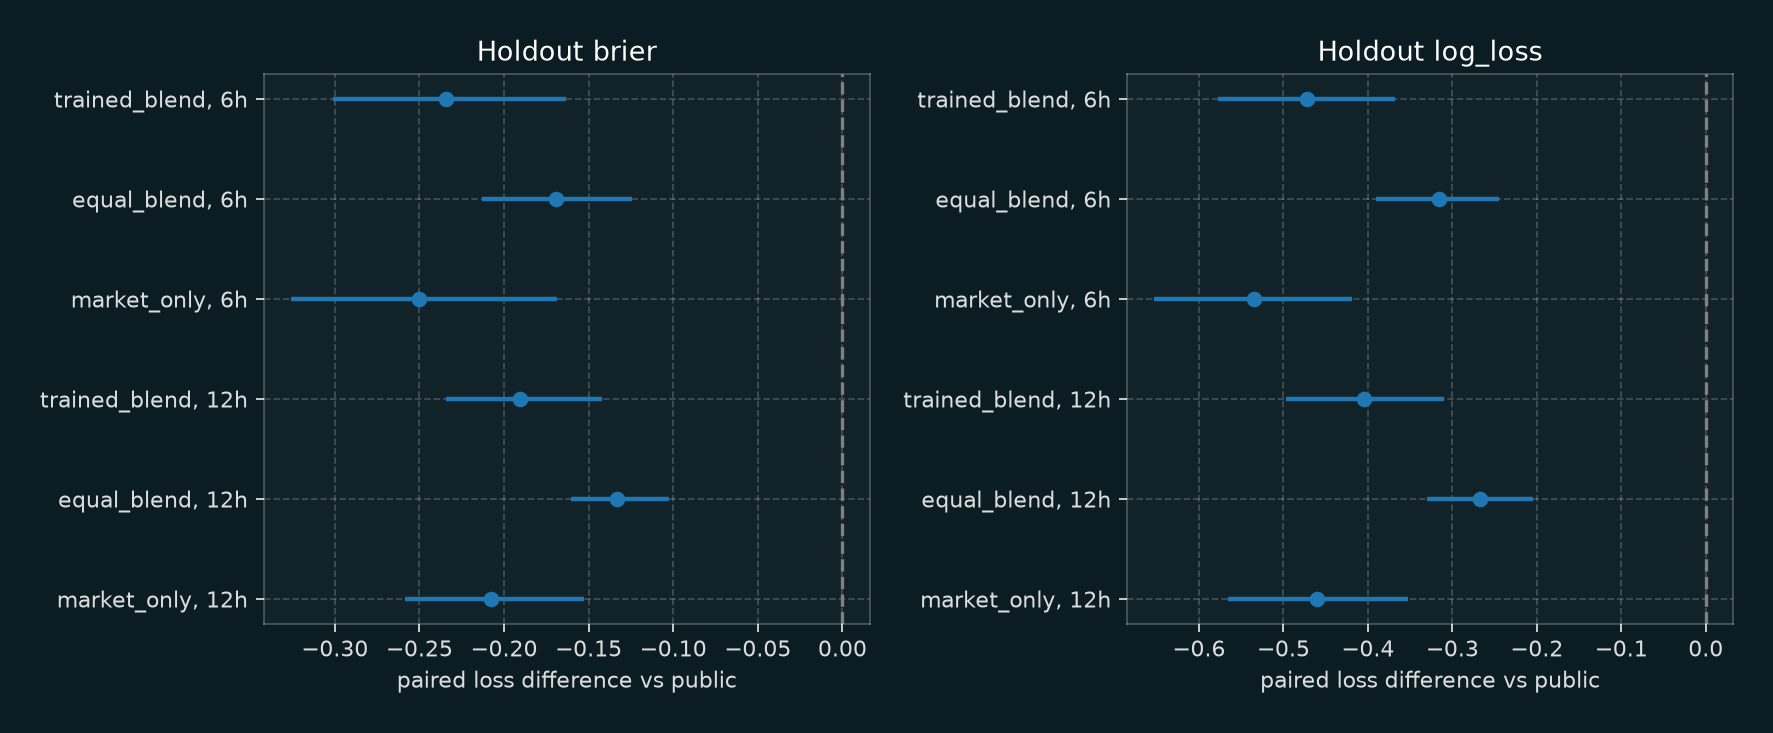

In [11]:
summaries = results["summaries"]
later_summaries = []
for s in summaries:
    if s['split'] in ('validation', 'holdout'):
        later_summaries.append(s)
summary_scores = pd.DataFrame(
    [
        {
            "split": s["split"],
            "horizon_hours": s["horizon_hours"],
            "method": method,
            "events": s["events"],
            "dates": s["dates"],
            **s["scores"][method],
        }
        for s in later_summaries
        for method in methods
    ]
)
display(summary_scores)
paired_rows = []
for s in later_summaries:
    for c in s["paired_comparisons"]:
        paired_rows.append(
            {
                "split": s["split"],
                "horizon_hours": s["horizon_hours"],
                "method": c["method"],
                "metric": c["metric"],
                "mean_difference": c["mean_difference"],
                "ci95": c["ci95"],
                "dates": s["dates"],
                "date_blocks_floor": s["date_block_count_floor"],
                "valid_replicates": c["valid_replicates"],
                "interval_unavailable_reason": c["interval_unavailable_reason"],
            }
        )
paired = pd.DataFrame(paired_rows)
display(paired)
_, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric in zip(axes, ("brier", "log_loss"), strict=True):
    subset = paired[(paired["split"] == "holdout") & (paired["metric"] == metric)]
    for j, (_, r) in enumerate(subset.iterrows()):
        ax.plot(r["mean_difference"], j, "o", color="C0")
        if r["ci95"] is not None:
            ax.hlines(j, *r["ci95"], color="C0", linewidth=2)
    ax.set_yticks(
        range(len(subset)), [f"{r.method}, {r.horizon_hours}h" for r in subset.itertuples()]
    )
    ax.axvline(0, color="gray", linestyle="--")
    ax.set(title=f"Holdout {metric}", xlabel="paired loss difference vs public")
plt.tight_layout(pad=1.5)
plt.show()

In [12]:
block_rows = []
for s in summaries:
    if s["split"] != "holdout":
        continue
    for c in s["paired_comparisons"]:
        if c["method"] != "trained_blend":
            continue
        for block, value in c["block_sensitivity"].items():
            block_rows.append(
                {
                    "horizon_hours": s["horizon_hours"],
                    "metric": c["metric"],
                    "observed_dates_per_block": int(block),
                    "ci95": value["ci95"],
                    "valid_replicates": value["valid_replicates"],
                    "reason": value["interval_unavailable_reason"],
                }
            )
display(pd.DataFrame(block_rows))
print(results["interpretation"]["bootstrap"])
print(results["interpretation"]["bootstrap_calendar_gaps"])
print("holdout unique dates:", cases.loc[cases["split"].eq("holdout"), "outcome_date"].nunique())

,horizon_hours,metric,observed_dates_per_block,ci95,valid_replicates,reason
0,12,brier,1,"[-0.23411381394649544, -0.14230041701886922]",2000,None
1,12,brier,3,"[-0.22578312505885645, -0.1496453228680848]",2000,None
2,12,brier,7,"[-0.22416355300319452, -0.155190151200751]",2000,None
3,12,log_loss,1,"[-0.48929751074538097, -0.3121992492012286]",2000,None
4,12,log_loss,3,"[-0.48902209284795023, -0.30669102968995315]",2000,None
5,12,log_loss,7,"[-0.49944882502000787, -0.31176798441010484]",2000,None
6,6,brier,1,"[-0.3022006904785279, -0.1621979632715332]",2000,None
7,6,brier,3,"[-0.2920648067799595, -0.17713907616828695]",2000,None
8,6,brier,7,"[-0.2866217560227279, -0.18627473934626843]",2000,None
9,6,log_loss,1,"[-0.5802794458917312, -0.36292032165482785]",2000,None


circular moving blocks of sorted observed dates, all events/horizons retained; shared draws across methods and conditions
blocks count observed dates and may span missing calendar dates
holdout unique dates: 31


## can disagreement identify where market information helps?

the condition is fixed from training: high disagreement means the l1 distance between public and market vectors exceeds the training median. both methods are compared on the same cases within each group.

the direct interaction is `(method − public) in high disagreement − (method − public) in low disagreement`. it asks whether the paired effect differs between groups. looking for significance in one group and not the other would answer a different question. few dates or too many undefined resamples prevent an interval from being reported.

In [13]:
group_rows, interaction_rows = [], []
for s in summaries:
    if s["split"] != "holdout":
        continue
    for group, summary in s["conditions"]["groups"].items():
        for c in summary["paired_comparisons"]:
            group_rows.append(
                {
                    "horizon_hours": s["horizon_hours"],
                    "group": group,
                    "method": c["method"],
                    "metric": c["metric"],
                    "cases": summary["cases"],
                    "dates": summary["dates"],
                    "mean_difference": c["mean_difference"],
                    "ci95": c["ci95"],
                    "valid_replicates": c["valid_replicates"],
                    "reason": c["interval_unavailable_reason"],
                }
            )
    for c in s["conditions"]["interactions"]:
        interaction_rows.append(
            {
                "horizon_hours": s["horizon_hours"],
                "method": c["method"],
                "metric": c["metric"],
                "high_minus_low": c["mean_difference"],
                "ci95": c["ci95"],
                "valid_replicates": c["valid_replicates"],
                "undefined_replicates": c["undefined_replicates"],
                "reason": c["interval_unavailable_reason"],
            }
        )
print("frozen training l1 threshold:", fit["disagreement_l1_median"])
display(pd.DataFrame(group_rows))
display(pd.DataFrame(interaction_rows))

frozen training l1 threshold: 0.47491241127656764


,horizon_hours,group,method,metric,cases,dates,mean_difference,ci95,valid_replicates,reason
0,12,high,market_only,brier,26,26,-0.248326,"[-0.2897845507100636, -0.20348239045523664]",2000,NaN
1,12,high,market_only,log_loss,26,26,-0.540920,"[-0.631032266863158, -0.45702730901601557]",2000,NaN
2,12,high,equal_blend,brier,26,26,-0.156132,"[-0.17752896012542924, -0.13325120992923611]",2000,NaN
3,12,high,equal_blend,log_loss,26,26,-0.312133,"[-0.3703392770380846, -0.25950658673450155]",2000,NaN
4,12,high,trained_blend,brier,26,26,-0.225869,"[-0.2611775721924876, -0.18794541222229996]",2000,NaN
5,12,high,trained_blend,log_loss,26,26,-0.474124,"[-0.5554658235545142, -0.3988670605723344]",2000,NaN
6,12,low,market_only,brier,5,5,0.001989,"[-0.1093637095322641, 0.12472800044384083]",1985,NaN
7,12,low,market_only,log_loss,5,5,-0.043259,"[-0.22799953054151834, 0.19602787746662942]",1985,NaN
8,12,low,equal_blend,brier,5,5,-0.013320,"[-0.06506077783239594, 0.04725072965991171]",1985,NaN
9,12,low,equal_blend,log_loss,5,5,-0.031314,"[-0.12048371254451418, 0.08246027669046785]",1985,NaN


,horizon_hours,method,metric,high_minus_low,ci95,valid_replicates,undefined_replicates,reason
0,12,market_only,brier,-0.250315,"[-0.37269348108694744, -0.13559188299837577]",1985,15,NaN
1,12,market_only,log_loss,-0.497661,"[-0.7375639655979435, -0.29298018012113314]",1985,15,NaN
2,12,equal_blend,brier,-0.142812,"[-0.20385224788142625, -0.08718282997014437]",1985,15,NaN
3,12,equal_blend,log_loss,-0.280819,"[-0.39432769737763845, -0.1775712780886662]",1985,15,NaN
4,12,trained_blend,brier,-0.219866,"[-0.32256531407115285, -0.1244843139641709]",1985,15,NaN
5,12,trained_blend,log_loss,-0.432267,"[-0.630851111329533, -0.260341218659112]",1985,15,NaN
6,6,market_only,brier,-0.387672,None,1764,236,insufficient_valid_bootstrap_replicates
7,6,market_only,log_loss,-0.643343,None,1764,236,insufficient_valid_bootstrap_replicates
8,6,equal_blend,brier,-0.226280,None,1764,236,insufficient_valid_bootstrap_replicates
9,6,equal_blend,log_loss,-0.373115,None,1764,236,insufficient_valid_bootstrap_replicates


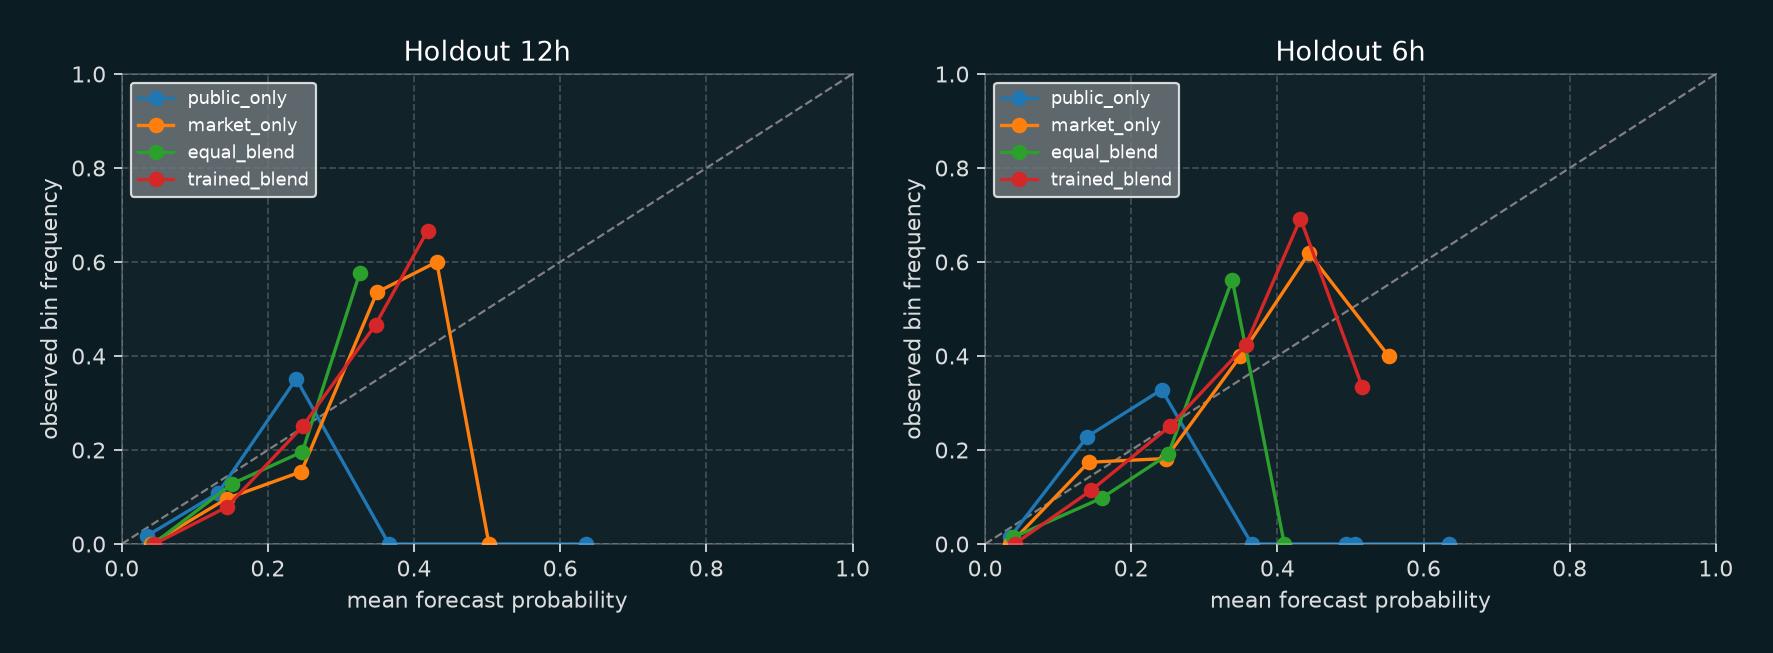

,horizon_hours,method,count,lower,mean_probability,observed_frequency,upper
0,12,public_only,58,0.0,0.034198,0.017241,0.1
1,12,public_only,37,0.1,0.131459,0.108108,0.2
2,12,public_only,74,0.2,0.238762,0.351351,0.3
3,12,public_only,16,0.3,0.365541,0.000000,0.4
4,12,public_only,1,0.6,0.635515,0.000000,0.7
5,12,market_only,85,0.0,0.040140,0.000000,0.1
6,12,market_only,31,0.1,0.143693,0.096774,0.2
7,12,market_only,26,0.2,0.245642,0.153846,0.3
8,12,market_only,28,0.3,0.349284,0.535714,0.4
9,12,market_only,15,0.4,0.430968,0.600000,0.5


In [14]:
# calibration is descriptive because bins from one event share an outcome
heldout_summaries = []
for s in summaries:
    if s['split'] == 'holdout':
        heldout_summaries.append(s)
_, axes = plt.subplots(1, len(heldout_summaries), figsize=(11, 4), squeeze=False)
calibration_rows = []
for ax, s in zip(axes.flat, heldout_summaries, strict=True):
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    for method in methods:
        bins = []
        for b in s['calibration'][method]:
            if b['count']:
                bins.append(b)
        ax.plot(
            [b["mean_probability"] for b in bins],
            [b["observed_frequency"] for b in bins],
            marker="o",
            label=method,
        )
        calibration_rows.extend(
            {"horizon_hours": s["horizon_hours"], "method": method, **b} for b in bins
        )
    ax.set(
        title=f"Holdout {s['horizon_hours']}h",
        xlabel="mean forecast probability",
        ylabel="observed bin frequency",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    ax.legend(fontsize=8)
plt.tight_layout(pad=1.5)
plt.show()
display(pd.DataFrame(calibration_rows))

## does the public predictive interval cover the realized high?

these are the saved central 90% intervals of the fitted normal temperature distribution, not confidence intervals for model performance. coverage uses each event's integer settlement value. the table keeps validation and holdout separate; neither was used to widen the intervals.

coverage near 90% in a small sample is weak evidence of calibration. the time plot makes clustered misses and systematic bias visible.

,split,horizon_hours,events,dates,nominal_coverage,observed_coverage,mean_outcome_minus_public_f
0,train,12,30,30,0.9,0.833333,0.263241
1,train,6,30,30,0.9,0.833333,0.035241
2,validation,12,31,31,0.9,0.935484,1.669499
3,validation,6,31,31,0.9,0.967742,1.297887
4,holdout,12,31,31,0.9,1.000000,1.473370
5,holdout,6,31,31,0.9,1.000000,1.711435


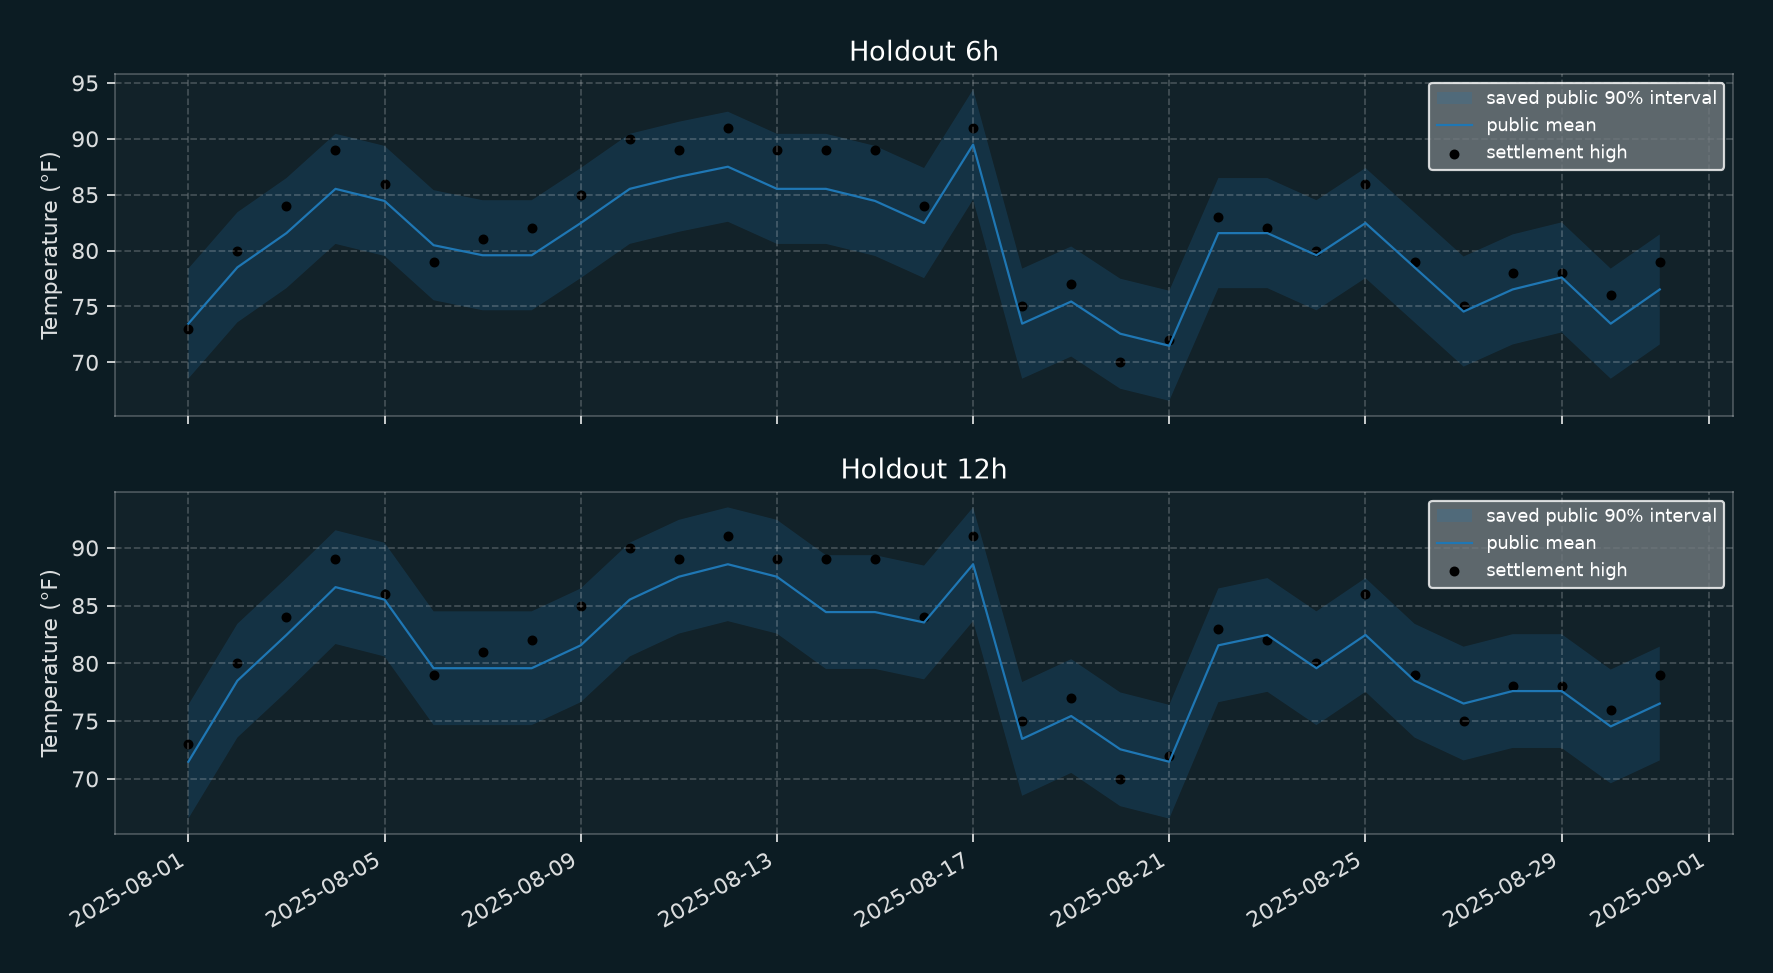

In [15]:
coverage = pd.DataFrame(
    [
        {
            "split": s["split"],
            "horizon_hours": s["horizon_hours"],
            "events": s["events"],
            "dates": s["dates"],
            "nominal_coverage": .9,
            "observed_coverage": s["public_interval90_observed_coverage"],
            "mean_outcome_minus_public_f": s["public_mean_error_f"],
        }
        for s in summaries
    ]
)
display(coverage)
holdout = cases[cases["split"] == "holdout"].copy()
fig, axes = plt.subplots(len(heldout_summaries), 1, figsize=(11, 6), squeeze=False)
for ax, (horizon, group) in zip(axes.flat, holdout.groupby("horizon_hours"), strict=True):
    group = group.sort_values("outcome_date")
    dates = pd.to_datetime(group["outcome_date"])
    ax.fill_between(
        dates,
        group["public_interval90_lower_f"].to_numpy(),
        group["public_interval90_upper_f"].to_numpy(),
        alpha=.2,
        label="saved public 90% interval",
    )
    ax.plot(dates, group["public_mean_f"], label="public mean", linewidth=1)
    ax.scatter(dates, group["outcome_f"], color="black", s=12, label="settlement high")
    ax.set(title=f"Holdout {horizon}h", ylabel="Temperature (°F)")
    ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout(pad=1.5)
plt.show()

## inspect one failure case after evaluation

the example below is selected descriptively: it has the largest held-out `trained blend − public` brier difference. if every difference is negative, it is the smallest observed benefit instead of a harmful prediction. this selection is not a forecasting rule or an estimate of typical performance.

inspecting its forecast, bins, prices, and outcome helps explain an error. it does not authorize changing the model or calling the new explanation a prespecified condition.

post-evaluation example: KXHIGHNY-25AUG06-6h ; paired brier difference: 0.2478331144252588


,case
as_of_at,2025-08-05T23:00:00+00:00
forecast_f,81.95
public_mean_f,80.482759
outcome_f,79.0
ncei_tmax_f,79.0
disagreement_l1,0.711204
disagreement_group,high


,equal_blend,market_only,public_only,trained_blend,observed_winner
KXHIGHNY-25AUG06-T79,0.138841,0.023810,0.253873,0.060494,0
KXHIGHNY-25AUG06-B79.5,0.212308,0.176190,0.248425,0.187709,1
KXHIGHNY-25AUG06-B81.5,0.409467,0.571429,0.247506,0.519778,0
KXHIGHNY-25AUG06-B83.5,0.175436,0.190476,0.160396,0.185680,0
KXHIGHNY-25AUG06-B85.5,0.040938,0.014286,0.067590,0.022785,0
KXHIGHNY-25AUG06-T86,0.023010,0.023810,0.022210,0.023555,0


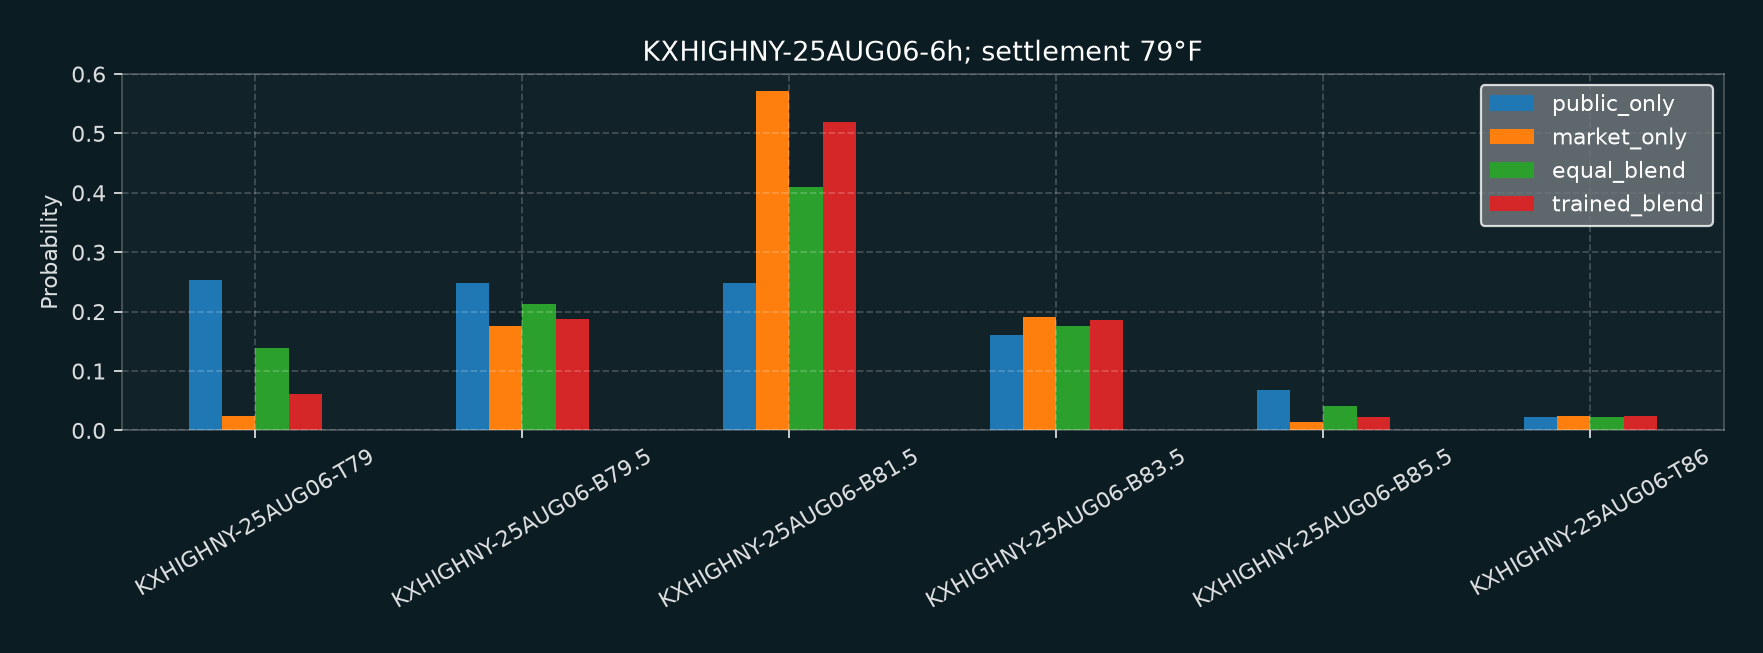

,ask_dollars,bid_dollars,candle_age_minutes,candle_end_at,probability,spread
KXHIGHNY-25AUG06-T79,0.0400,0.0100,0.0,2025-08-05T23:00:00+00:00,0.025,0.03
KXHIGHNY-25AUG06-B79.5,0.2100,0.1600,0.0,2025-08-05T23:00:00+00:00,0.185,0.05
KXHIGHNY-25AUG06-B81.5,0.6200,0.5800,0.0,2025-08-05T23:00:00+00:00,0.600,0.04
KXHIGHNY-25AUG06-B83.5,0.2200,0.1800,0.0,2025-08-05T23:00:00+00:00,0.200,0.04
KXHIGHNY-25AUG06-B85.5,0.0300,0.0000,0.0,2025-08-05T23:00:00+00:00,0.015,0.03
KXHIGHNY-25AUG06-T86,0.0500,0.0000,0.0,2025-08-05T23:00:00+00:00,0.025,0.05


In [16]:
failure = max(
    (r for r in records if r["split"] == "holdout"),
    key=lambda r: r["scores"]["trained_blend"]["brier"] - r["scores"]["public_only"]["brier"],
)
difference = failure["scores"]["trained_blend"]["brier"] - failure["scores"]["public_only"]["brier"]
print("post-evaluation example:", failure["case_id"], "; paired brier difference:", difference)
if difference <= 0:
    print("no holdout difference is positive; this case has the smallest observed benefit.")
display(
    pd.Series(
        {
            key: failure[key]
            for key in (
                "as_of_at",
                "forecast_f",
                "public_mean_f",
                "outcome_f",
                "ncei_tmax_f",
                "disagreement_l1",
                "disagreement_group",
            )
        },
        name="case",
    ).to_frame()
)
case_probabilities = pd.DataFrame(
    failure["probabilities"], index=[b["ticker"] for b in failure["bins"]]
)
case_probabilities["observed_winner"] = [
    int(i == failure["winner_index"]) for i in range(len(failure["bins"]))
]
display(case_probabilities)
case_probabilities[list(methods)].plot.bar(figsize=(11, 4), rot=30)
plt.ylabel("Probability")
plt.title(f"{failure['case_id']}; settlement {failure['outcome_f']:.0f}°F")
plt.tight_layout(pad=1.5)
plt.show()
display(pd.DataFrame(failure["market_observations"], index=case_probabilities.index))

## what this run supports

the statements below come from the saved primary comparison. they apply to this one-city summer reconstruction. a wider claim needs more dates, seasons, and independently mapped cities.

historical availability is reconstructed, archived rules may have changed, the daytime grid maximum differs from the station's full-day maximum, and the holdout contains one month. marginal intervals do not settle every conditional question, and a null result is not proof of equivalence.

In [17]:
for s in heldout_summaries:
    contrast = next(
        c
        for c in s["paired_comparisons"]
        if c["method"] == "trained_blend" and c["metric"] == "brier"
    )
    delta, interval = contrast["mean_difference"], contrast["ci95"]
    if interval is None:
        interpretation = "a 95% interval is unavailable: " + contrast["interval_unavailable_reason"]
    elif interval[1] < 0:
        interpretation = "the marginal interval favors the trained blend in this cohort."
    elif interval[0] > 0:
        interpretation = "the marginal interval favors public-only in this cohort."
    else:
        interpretation = "the interval includes zero; it does not establish equivalence."
    display(
        Markdown(
            f"{s['horizon_hours']}h checkpoint: trained-minus-public brier {delta:.4f}, "
            f"95% interval `{interval}`, over {s['dates']} dates. {interpretation}"
        )
    )
for limitation in protocol["limitations"]:
    print("•", limitation)

12h checkpoint: trained-minus-public brier -0.1904, 95% interval `[-0.2341560455470882, -0.14193784191893988]`, over 31 dates. the marginal interval favors the trained blend in this cohort.

6h checkpoint: trained-minus-public brier -0.2341, 95% interval `[-0.3008344746599422, -0.1636376844163688]`, over 31 dates. the marginal interval favors the trained blend in this cohort.

• Single city and summer season; this is not evidence of general year-round or cross-city performance.
• Archive metadata supports reconstruction, not proof of all information available to a real-time trader.
• Historical rules may have later updates; original publication snapshots are not available.
• Hourly candle bid/ask closes do not establish executable fills or historical depth.
• NDFD grid daytime maximum differs from the station's full-day maximum.
• One month of holdout dates limits statistical precision; null and adverse findings are retained.


In [18]:
# point to the saved run without overwriting it
print("panel:", panel_path.relative_to(repo))
print("results:", results_path.relative_to(repo))
print("canonical panel sha-256:", results["input_panel_sha256"])
print("source data were read locally; no model was fitted in this notebook.")
con.close()

panel: outputs/historical-study/panel.json
results: outputs/historical-study/analysis/historical-results.json
canonical panel sha-256: d4b482321ab309083f0dd35307f2c2fefff84fe93946bf1e04a14d9f18e8c110
source data were read locally; no model was fitted in this notebook.
